# 09 — Error Analysis: V1-Fixed Model (51.8%)

Categorize and visualize the failure modes of our best model (v1-fixed, 51.8% execution accuracy).

**Error categories:**
- `correct` — execution result matches gold
- `syntax_error` — SQL fails to parse or execute
- `wrong_column` — wrong SELECT column
- `wrong_agg` — wrong aggregation function
- `wrong_where_col` — WHERE references wrong column(s)
- `wrong_where_op` — WHERE uses wrong operator
- `wrong_where_val` — WHERE uses wrong value(s)
- `missing_where` — prediction missing WHERE clause(s)
- `extra_where` — prediction has extra WHERE clause(s)
- `multiple_errors` — more than one of the above
- `wrong_result_other` — parsed components look correct but results differ

In [1]:
import json
import sys
import os

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/sixuan/Documents/Code/text-to-sql-llama copy


## 1. Load predictions and dataset

In [2]:
from datasets import load_dataset

# Load WikiSQL test set (same 500 examples used in all experiments)
ds = load_dataset('Salesforce/wikisql')
test_examples = list(ds['test'].select(range(500)))
print(f'Loaded {len(test_examples)} test examples')

# Load v1-fixed predictions
with open(os.path.join(PROJECT_ROOT, 'results', 'controlled_comparison_results.json')) as f:
    results = json.load(f)

predictions = results['v1_fixed']['predictions']
print(f'Loaded {len(predictions)} predictions')
print(f'Example: {predictions[0]}')

Loaded 500 test examples
Loaded 500 predictions
Example: SELECT `Nationality` FROM table WHERE `Player` = 'Terrence Ross'


## 2. Run error analysis

In [3]:
from src.eval.error_analysis import analyze_predictions

analysis = analyze_predictions(predictions, test_examples)

print('=== Error Category Summary ===')
print(f"Total examples: {analysis['total']}")
print()
for cat, count in sorted(analysis['summary'].items(), key=lambda x: -x[1]):
    pct = count / analysis['total'] * 100
    print(f'  {cat:25s}  {count:4d}  ({pct:5.1f}%)')

=== Error Category Summary ===
Total examples: 500

  correct                     259  ( 51.8%)
  multiple_errors              71  ( 14.2%)
  wrong_result_other           52  ( 10.4%)
  wrong_where_val              47  (  9.4%)
  syntax_error                 27  (  5.4%)
  wrong_column                 26  (  5.2%)
  wrong_agg                    10  (  2.0%)
  wrong_where_col               7  (  1.4%)
  extra_where                   1  (  0.2%)


## 3. Error distribution (bar chart)

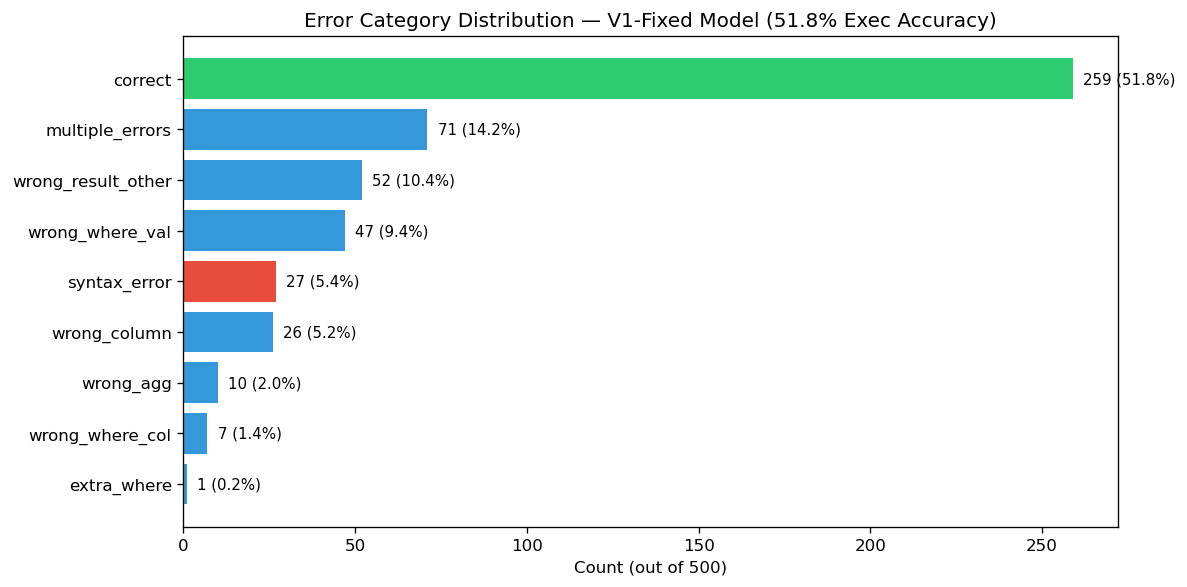

Saved: results/error_analysis_distribution.png


In [4]:
summary = analysis['summary']

# Order: correct first, then errors by frequency
correct_count = summary.pop('correct', 0)
error_cats = sorted(summary.items(), key=lambda x: -x[1])
categories = ['correct'] + [c for c, _ in error_cats]
counts = [correct_count] + [n for _, n in error_cats]
# Restore
summary['correct'] = correct_count

colors = ['#2ecc71'] + ['#e74c3c' if c == 'syntax_error' else '#3498db' for c, _ in error_cats]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(categories[::-1], counts[::-1], color=colors[::-1])
ax.set_xlabel('Count (out of 500)')
ax.set_title('Error Category Distribution — V1-Fixed Model (51.8% Exec Accuracy)')

# Add count labels
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'{count} ({count/500*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'error_analysis_distribution.png'),
            bbox_inches='tight')
plt.show()
print('Saved: results/error_analysis_distribution.png')

## 4. Error breakdown (pie chart)

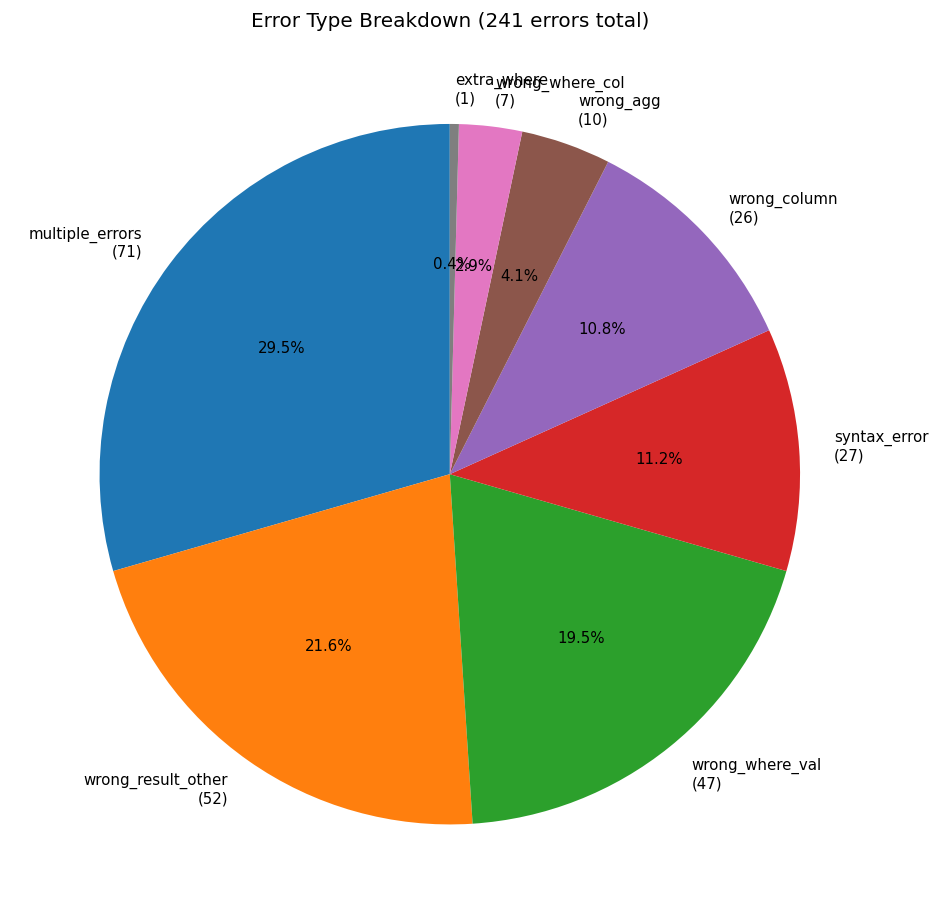

Saved: results/error_analysis_pie.png


In [5]:
# Pie chart of errors only (exclude correct)
error_only = {k: v for k, v in summary.items() if k != 'correct'}
total_errors = sum(error_only.values())

labels = [f"{k}\n({v})" for k, v in sorted(error_only.items(), key=lambda x: -x[1])]
sizes = [v for _, v in sorted(error_only.items(), key=lambda x: -x[1])]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 9}
)
ax.set_title(f'Error Type Breakdown ({total_errors} errors total)')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'error_analysis_pie.png'),
            bbox_inches='tight')
plt.show()
print('Saved: results/error_analysis_pie.png')

## 5. Example failures by category

Show 2 representative examples per error category to understand common failure patterns.

In [6]:
from collections import defaultdict

# Group examples by category
by_category = defaultdict(list)
for ex in analysis['examples']:
    by_category[ex['category']].append(ex)

# Show 2 examples per error category
for cat in sorted(by_category.keys()):
    if cat == 'correct':
        continue
    examples = by_category[cat][:2]
    print(f'\n{"=" * 60}')
    print(f'Category: {cat} ({len(by_category[cat])} total)')
    print(f'{"=" * 60}')
    for ex in examples:
        print(f'\n  [Index {ex["index"]}] Q: {ex["question"]}')
        print(f'  Gold: {ex["gold_sql"]}')
        print(f'  Pred: {ex["predicted_sql"]}')
        if ex['details'] and isinstance(ex['details'], str):
            print(f'  Error: {ex["details"][:120]}')


Category: extra_where (1 total)

  [Index 87] Q: In what year was the last last title received, by any of the countries?
  Gold: SELECT MAX(`Last title`) FROM table
  Pred: SELECT MAX(`Last title`) FROM table WHERE `First title` = 1999

Category: multiple_errors (71 total)

  [Index 4] Q: Where was Assen held?
  Gold: SELECT `Round` FROM table WHERE `Circuit` = 'Assen'
  Pred: SELECT `Circuit` FROM table WHERE `Date` = 'Assen'

  [Index 19] Q: Give me a list of all spanish officer titles that could receive recognition as group captain in english
  Gold: SELECT `Rank in English` FROM table WHERE `Commonwealth equivalent` = 'Group Captain'
  Pred: SELECT `Rank in Spanish` FROM table WHERE `Equivalent NATO Rank Code` = 'Group Captain'

Category: syntax_error (27 total)

  [Index 25] Q: What rank was Bryan Danielson in this chart?
  Gold: SELECT `Rank Each wrestlers total number of days as champion are ranked highest to lowest; wrestlers with the same number mean that they are tied for th

## 6. Syntax error deep-dive

Look at common patterns in syntax errors — what is the model generating that SQLite can't parse?

In [7]:
syntax_errors = by_category.get('syntax_error', [])
print(f'Total syntax errors: {len(syntax_errors)}')
print()

# Categorize syntax error messages
error_messages = defaultdict(int)
for ex in syntax_errors:
    msg = ex['details']
    # Normalize: strip specific values to find patterns
    if 'no such column' in msg:
        error_messages['no such column'] += 1
    elif 'near' in msg:
        error_messages['near (syntax)'] += 1
    elif 'no such table' in msg:
        error_messages['no such table'] += 1
    elif 'unrecognized token' in msg:
        error_messages['unrecognized token'] += 1
    else:
        error_messages[msg[:60]] += 1

print('Syntax error patterns:')
for msg, count in sorted(error_messages.items(), key=lambda x: -x[1]):
    print(f'  {count:3d}  {msg}')

if syntax_errors:
    print(f'\n--- First 5 syntax error predictions ---')
    for ex in syntax_errors[:5]:
        print(f'  [{ex["index"]}] {ex["predicted_sql"][:100]}')
        print(f'       Error: {ex["details"][:100]}')

Total syntax errors: 27

Syntax error patterns:
   15  no such column
   10  near (syntax)
    2  unrecognized token

--- First 5 syntax error predictions ---
  [25] SELECT `Rank` FROM table WHERE `Wrestler` = 'Bryan Danielson'
       Error: no such column: Rank
  [27] SELECT `Rank` FROM table WHERE `Wrestler` = 'Go Shiozaki'
       Error: no such column: Rank
  [47] SELECT `Tone` FROM table WHERE `Nominative` = 'gen.sg.plague'
       Error: no such column: Tone
  [64] SELECT COUNT(`Significant Relationship`) FROM table WHERE `Virtue` = 'Will'
       Error: no such column: Virtue
  [70] SELECT `% `McConnell`` FROM table WHERE `County` = 'Letcher' AND `% `Lunsford`` = '51.82%'
       Error: near "``": syntax error


## 7. WHERE clause analysis

Since WHERE errors are often the largest bucket, look at how WHERE complexity correlates with errors.

Accuracy by number of WHERE conditions:
   # WHERE   Total   Correct    Accuracy
----------------------------------------
         0      11         8       72.7%
         1     457       241       52.7%
         2      31        10       32.3%
         3       1         0        0.0%


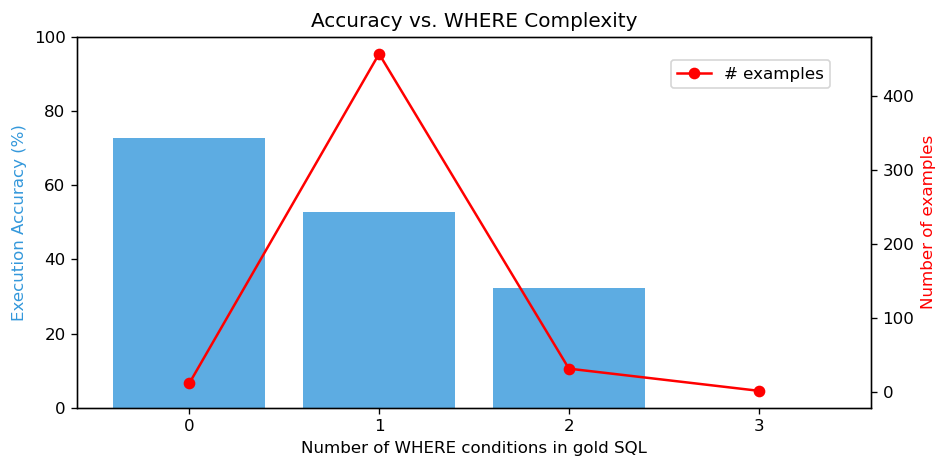

Saved: results/error_analysis_where_complexity.png


In [8]:
# Accuracy by number of gold WHERE conditions
from collections import Counter

acc_by_where = defaultdict(lambda: {'correct': 0, 'total': 0})

for ex in analysis['examples']:
    idx = ex['index']
    n_conds = len(test_examples[idx]['sql']['conds']['column_index'])
    acc_by_where[n_conds]['total'] += 1
    if ex['category'] == 'correct':
        acc_by_where[n_conds]['correct'] += 1

print('Accuracy by number of WHERE conditions:')
print(f'{"# WHERE":>10s}  {"Total":>6s}  {"Correct":>8s}  {"Accuracy":>10s}')
print('-' * 40)
for n in sorted(acc_by_where.keys()):
    d = acc_by_where[n]
    acc = d['correct'] / d['total'] * 100 if d['total'] > 0 else 0
    print(f'{n:>10d}  {d["total"]:>6d}  {d["correct"]:>8d}  {acc:>9.1f}%')

# Bar chart
n_conds_list = sorted(acc_by_where.keys())
accs = [acc_by_where[n]['correct'] / acc_by_where[n]['total'] * 100 for n in n_conds_list]
totals = [acc_by_where[n]['total'] for n in n_conds_list]

fig, ax1 = plt.subplots(figsize=(8, 4))
bars = ax1.bar(n_conds_list, accs, color='#3498db', alpha=0.8)
ax1.set_xlabel('Number of WHERE conditions in gold SQL')
ax1.set_ylabel('Execution Accuracy (%)', color='#3498db')
ax1.set_xticks(n_conds_list)
ax1.set_ylim(0, 100)

# Overlay count
ax2 = ax1.twinx()
ax2.plot(n_conds_list, totals, 'ro-', markersize=6, label='# examples')
ax2.set_ylabel('Number of examples', color='red')

ax1.set_title('Accuracy vs. WHERE Complexity')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'error_analysis_where_complexity.png'),
            bbox_inches='tight')
plt.show()
print('Saved: results/error_analysis_where_complexity.png')

## 8. Aggregation accuracy

How does the model perform on different aggregation types?

Accuracy by aggregation type:
     Agg   Total   Correct    Accuracy
--------------------------------------
    NONE     356       188       52.8%
     MAX      22        13       59.1%
     MIN      25        17       68.0%
   COUNT      97        41       42.3%


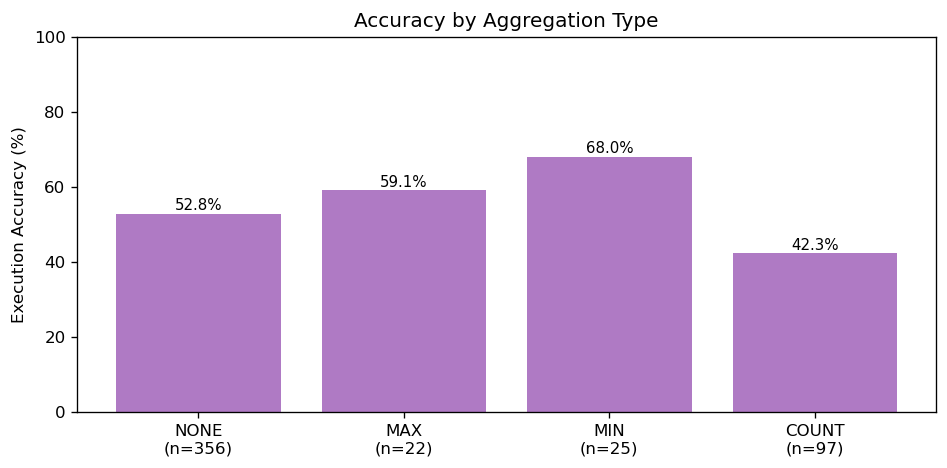

Saved: results/error_analysis_aggregation.png


In [9]:
from src.data.prepare_dataset import AGG_OPS

acc_by_agg = defaultdict(lambda: {'correct': 0, 'total': 0})

for ex in analysis['examples']:
    idx = ex['index']
    agg_idx = test_examples[idx]['sql']['agg']
    agg_name = AGG_OPS[agg_idx] if AGG_OPS[agg_idx] else 'NONE'
    acc_by_agg[agg_name]['total'] += 1
    if ex['category'] == 'correct':
        acc_by_agg[agg_name]['correct'] += 1

print('Accuracy by aggregation type:')
print(f'{"Agg":>8s}  {"Total":>6s}  {"Correct":>8s}  {"Accuracy":>10s}')
print('-' * 38)
for agg in ['NONE', 'MAX', 'MIN', 'COUNT', 'SUM', 'AVG']:
    if agg in acc_by_agg:
        d = acc_by_agg[agg]
        acc = d['correct'] / d['total'] * 100
        print(f'{agg:>8s}  {d["total"]:>6d}  {d["correct"]:>8d}  {acc:>9.1f}%')

# Bar chart
agg_names = [a for a in ['NONE', 'MAX', 'MIN', 'COUNT', 'SUM', 'AVG'] if a in acc_by_agg]
agg_accs = [acc_by_agg[a]['correct'] / acc_by_agg[a]['total'] * 100 for a in agg_names]
agg_totals = [acc_by_agg[a]['total'] for a in agg_names]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(agg_names))
bars = ax.bar(x, agg_accs, color='#9b59b6', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n(n={t})' for n, t in zip(agg_names, agg_totals)])
ax.set_ylabel('Execution Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Accuracy by Aggregation Type')

for bar, acc in zip(bars, agg_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'results', 'error_analysis_aggregation.png'),
            bbox_inches='tight')
plt.show()
print('Saved: results/error_analysis_aggregation.png')

## 9. Save full analysis to JSON

In [10]:
# Save analysis results
output = {
    'model': 'v1_fixed (51.8% exec accuracy)',
    'total': analysis['total'],
    'summary': analysis['summary'],
    'accuracy_by_where_conditions': {
        str(k): v for k, v in acc_by_where.items()
    },
    'accuracy_by_aggregation': {
        k: v for k, v in acc_by_agg.items()
    },
    'per_example': [
        {
            'index': ex['index'],
            'category': ex['category'],
            'question': ex['question'],
            'predicted_sql': ex['predicted_sql'],
            'gold_sql': ex['gold_sql'],
        }
        for ex in analysis['examples']
        if ex['category'] != 'correct'
    ]
}

output_path = os.path.join(PROJECT_ROOT, 'results', 'error_analysis_v1_fixed.json')
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f'Saved detailed error analysis to: results/error_analysis_v1_fixed.json')
print(f'Contains {len(output["per_example"])} error examples (correct ones excluded)')

Saved detailed error analysis to: results/error_analysis_v1_fixed.json
Contains 241 error examples (correct ones excluded)


## 10. Summary

Key findings from error analysis of the v1-fixed model on 500 test examples.

In [11]:
print('=== Error Analysis Summary ===')
print(f'Model: v1-fixed (QLoRA + chat template fix)')
print(f'Test set: 500 WikiSQL examples')
print()

total = analysis['total']
correct = analysis['summary'].get('correct', 0)
print(f'Execution accuracy: {correct}/{total} ({correct/total*100:.1f}%)')
print(f'Total errors: {total - correct}')
print()

print('Top error categories:')
for cat, count in sorted(
    [(k, v) for k, v in analysis['summary'].items() if k != 'correct'],
    key=lambda x: -x[1]
)[:5]:
    print(f'  {cat:25s}  {count:4d}  ({count/total*100:.1f}%)')

=== Error Analysis Summary ===
Model: v1-fixed (QLoRA + chat template fix)
Test set: 500 WikiSQL examples

Execution accuracy: 259/500 (51.8%)
Total errors: 241

Top error categories:
  multiple_errors              71  (14.2%)
  wrong_result_other           52  (10.4%)
  wrong_where_val              47  (9.4%)
  syntax_error                 27  (5.4%)
  wrong_column                 26  (5.2%)
